## Industrial Pump Condition Monitoring using Machine Learning

## Acoustic-Based Classification of Normal and Abnormal Pump Operating Conditions

---

### Author

**Abhishek Kumar**

Department of Operations Research & Data Analytics

Indian Institute of Technology Kharagpur

---

### Problem Statement

Unexpected pump failures in industrial environments can lead to costly downtime, production losses, expensive emergency maintenance, and potential safety risks.

Industrial pumps generate characteristic acoustic signatures during operation. Changes in these sound patterns often indicate abnormal operating conditions caused by mechanical degradation, cavitation, bearing wear, or other developing faults.

This project investigates whether machine learning can automatically distinguish between normal and abnormal pump operating conditions using acoustic (.wav) recordings. 

### Project Objectives
- Analyze acoustic recordings collected from industrial pumps under different operating conditions.
- Extract informative acoustic features from raw audio recordings.
- Perform exploratory data analysis.
- Develop, compare and optimize multiple machine learning classification models.
- Optimize model performance.
- Interpret prediction using Explainable AI (SHAP).

### Dataset Summary

- Data Type: .wav audio files
- Number of Samples: ~1000
- Classes:
    - Normal
    - Abnormal

### Dataset Characteristics

| Property | Value |
|----------|-------|
| Data Format | .wav |
| Problem Type | Binary Classification |
| Domain | Industrial Condition Monitoring |
| Input | Acoustic Signals |
| Output | Normal / Abnormal |

### Technology Stack

- Python
- Librosa
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- SHAP

### End-to-End Project Pipeline

Raw .wav Audio Files
        │
        ▼
Audio Loading
        │
        ▼
Feature Extraction
        │
        ▼
Feature Dataset
        │
        ▼
Exploratory Data Analysis
        │
        ▼
Data Preprocessing
        │
        ▼
Machine Learning Models
        │
        ▼
Model Evaluation
        │
        ▼
SHAP Explainability
        │
        ▼
Business Insights



---
## 🎯 Final Goal

Build an interpretable machine learning pipeline capable of automatically distinguishing between normal and abnormal industrial pump operating conditions using acoustic signal analysis.

Machine learning projects rely on multiple specialized Python libraries, each serving a specific purpose within the pipeline. Before loading and analyzing the dataset, all required libraries are imported to support audio processing, data manipulation, visualization, model development, and evaluation.

The following libraries will be used throughout this project.

In [4]:
# File and directory handling
import os

# Suppress unnecessary warnings
import warnings

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Audio processing
import librosa
import librosa.display

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Verify Library Versions

Recording the versions of important libraries improves reproducibility. If the project is revisited in the future or executed on another system, matching library versions helps ensure consistent results.

In [5]:
print("NumPy version:         ", np.__version__)
print("Pandas version:        ", pd.__version__)
print("Librosa version:       ", librosa.__version__)
print("Matplotlib version:    ", plt.matplotlib.__version__)
print("Seaborn version:       ", sns.__version__)

NumPy version:          2.4.6
Pandas version:         3.0.3
Librosa version:        0.11.0
Matplotlib version:     3.11.0
Seaborn version:        0.13.2


## Dataset Exploration

Before extracting audio features, it is important to understand the structure of the dataset.

This section explores:

- Directory structure
- Number of audio files
- Class distribution
- File names
- Sample audio properties

In [6]:
from pathlib import Path

DATA_DIR = Path("../data/raw")

pump_ids = sorted(DATA_DIR.glob("id_*"))

print("=" * 50)
print("Available Pump IDs")
print("=" * 50)

for i, pump in enumerate(pump_ids, start=1):
    print(f"{i}. {pump.name}")

print("=" * 50)
print(f"Total Pump IDs: {len(pump_ids)}")

Available Pump IDs
1. id_00
2. id_02
3. id_04
4. id_06
Total Pump IDs: 4


# Dataset Overview

Before performing any machine learning or feature extraction, it is important to understand the structure and distribution of the dataset.

This section explores the available pump IDs and analyzes the distribution of normal and abnormal audio recordings across different pumps. Understanding the dataset at this stage helps identify potential imbalance, missing data, or inconsistencies before proceeding with further analysis.

### Engineering Question

How many pump IDs are available, and how are the audio recordings distributed across normal and abnormal operating conditions?

In [7]:
from pathlib import Path

DATA_DIR = Path("../data/raw")

pump_ids = sorted(DATA_DIR.glob("id_*"))

print("=" * 50)
print("Available Pump IDs")
print("=" * 50)

for i, pump in enumerate(pump_ids, start=1):
    print(f"{i}. {pump.name}")

print("=" * 50)
print(f"Total Pump IDs: {len(pump_ids)}")

Available Pump IDs
1. id_00
2. id_02
3. id_04
4. id_06
Total Pump IDs: 4


### Observation

The dataset contains four pump IDs:

- id_00
- id_02
- id_04
- id_06

Each pump ID represents a separate collection of audio recordings that include both normal and abnormal operating conditions. This organization allows us to analyze data both at the overall dataset level and at the individual pump level.

## Distribution of Audio Recordings

### Engineering Question

How many normal and abnormal recordings are available for each pump ID?

Answering this question helps verify whether the dataset is balanced across different operating conditions and whether any pump contributes disproportionately to the dataset.

## Distribution of Audio Recordings

### Engineering Question

How many normal and abnormal audio recordings are available for each pump ID?

Understanding the distribution of recordings across different operating conditions helps verify whether the dataset is balanced and whether each pump contributes equally to the analysis.

In [8]:
# ==========================================================
# Distribution of Audio Recordings Across Pump IDs
# ==========================================================

print("=" * 65)
print(f"{'Pump ID':<15}{'Normal':<15}{'Abnormal':<15}{'Total':<15}")
print("=" * 65)

total_normal = 0
total_abnormal = 0

for pump in pump_ids:

    # Define the normal and abnormal folders
    normal_folder = pump / "normal"
    abnormal_folder = pump / "abnormal"

    # Count the number of WAV files
    normal_count = len(list(normal_folder.glob("*.wav")))
    abnormal_count = len(list(abnormal_folder.glob("*.wav")))

    # Total recordings for the current pump
    total_count = normal_count + abnormal_count

    # Update overall totals
    total_normal += normal_count
    total_abnormal += abnormal_count

    # Display the results
    print(f"{pump.name:<15}{normal_count:<15}{abnormal_count:<15}{total_count:<15}")

print("=" * 65)

grand_total = total_normal + total_abnormal

print(f"{'Total':<15}{total_normal:<15}{total_abnormal:<15}{grand_total:<15}")

print("=" * 65)

Pump ID        Normal         Abnormal       Total          
id_00          10             143            153            
id_02          9              111            120            
id_04          254            100            354            
id_06          139            102            241            
Total          412            456            868            


### Observation

The dataset contains **868 audio recordings** collected from four different pump IDs.

The overall distribution consists of **412 normal** recordings and **456 abnormal** recordings, indicating that the dataset is reasonably balanced at the global level.

However, the distribution across individual pump IDs is not uniform. Some pumps contain considerably more abnormal recordings, while others contain more normal recordings.

This observation suggests that future model evaluation should consider the distribution across pump IDs rather than relying solely on overall dataset statistics. It also highlights the importance of performing exploratory data analysis before feature extraction and model training.

Phase 1.2 — Audio Dataset Inspection

# Audio Dataset Inspection

## Engineering Question

Are all audio recordings valid and consistent for feature extraction?

Before extracting acoustic features, it is important to inspect the raw audio files. This helps verify that the recordings are readable, have consistent sampling rates, and contain valid audio signals.

The findings from this section will determine whether any preprocessing is required before feature engineering.

In [9]:
import librosa
import numpy as np
import pandas as pd

In [13]:
sample_file = next((DATA_DIR / "id_00" / "normal").glob("*.wav"))

print(sample_file)

../data/raw/id_00/normal/00000879.wav


In [14]:
audio, sample_rate = librosa.load(sample_file, sr=None)

In [15]:
print("Sample Rate:", sample_rate)
print("Number of Samples:", len(audio))
print("Data Type:", audio.dtype)

Sample Rate: 16000
Number of Samples: 160000
Data Type: float32


In [16]:
duration = len(audio) / sample_rate

print(f"Recording Duration: {duration:.2f} seconds")

Recording Duration: 10.00 seconds


### Observation

The sample recording was successfully loaded using Librosa.

The recording contains:

- Sampling Rate
- Number of Samples
- Duration

This confirms that the audio files are readable and provides the basic metadata required before feature extraction.

## Waveform Visualization

### Engineering Question

What does the raw audio waveform look like?

Visualizing the waveform provides an initial understanding of how the sound signal changes over time and helps identify unusual patterns, silence, clipping, or noise before feature extraction.

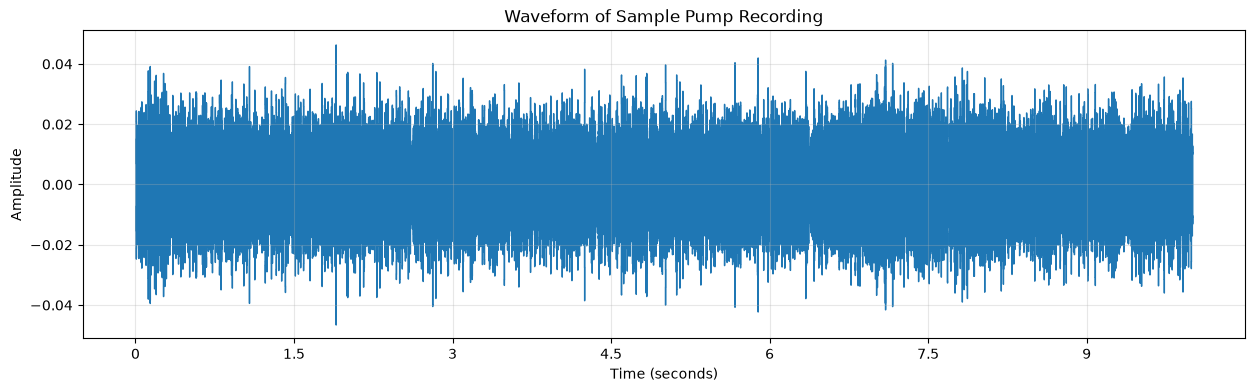

In [18]:
plt.figure(figsize=(15, 4))

librosa.display.waveshow(audio, sr=sample_rate)

plt.title("Waveform of Sample Pump Recording")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.grid(alpha=0.3)

plt.show()

### Observation

The waveform represents the variation of the acoustic signal amplitude over time.

Although the waveform alone cannot distinguish between normal and abnormal pump conditions, it provides an initial visual inspection of the recording quality and signal characteristics.

This visualization confirms that the recording contains meaningful acoustic information and is suitable for further signal processing and feature extraction.

## Listen to the Sample Recording

The following audio player allows the selected pump recording to be played directly inside the notebook. Listening to the signal complements waveform visualization and can help identify audible differences between normal and abnormal operating conditions.

In [19]:
from IPython.display import Audio

Audio(sample_file)

In [20]:
from IPython.display import Audio

Audio(audio, rate=sample_rate)

# Dataset Integrity Verification

## Engineering Question

Are all audio recordings readable, and do they share the same sampling rate and recording duration?

Rather than validating only a single recording, this section inspects every audio file in the dataset. This helps identify corrupted files, inconsistent recording lengths, or varying sampling rates that could negatively affect feature extraction and model performance.

In [21]:
audio_summary = []

for pump in pump_ids:

    for condition in ["normal", "abnormal"]:

        folder = pump / condition

        for wav_file in folder.glob("*.wav"):

            try:

                audio, sr = librosa.load(wav_file, sr=None)

                duration = len(audio) / sr

                audio_summary.append({
                    "Pump ID": pump.name,
                    "Condition": condition,
                    "Filename": wav_file.name,
                    "Sample Rate": sr,
                    "Duration": duration
                })

            except Exception as e:

                print(f"Error loading {wav_file}: {e}")

In [22]:
audio_df = pd.DataFrame(audio_summary)

audio_df.head()

,Pump ID,Condition,Filename,Sample Rate,Duration
0,id_00,normal,00000879.wav,16000,10.0
1,id_00,normal,00000466.wav,16000,10.0
2,id_00,normal,00000788.wav,16000,10.0
3,id_00,normal,00000004.wav,16000,10.0
4,id_00,normal,00000809.wav,16000,10.0


In [23]:
print("Total audio files :", len(audio_df))
print()

print("Unique Sample Rates")
print(audio_df["Sample Rate"].unique())

print()

print("Unique Durations")
print(audio_df["Duration"].unique())

Total audio files : 868

Unique Sample Rates
[16000]

Unique Durations
[10.]
